# 23CSE301 Machine Learning Capstone — Regression

**Academic Year:** 2026–27  
**Track:** Regression  
**Dataset:** Life Expectancy Data  
**Target:** `Life expectancy`

## Problem Statement
Predict a country's life expectancy using demographic, health, immunization, economic and education-related indicators.

## Capstone requirements covered in this notebook
- Complete dataset audit and EDA
- Missing-value, duplicate and outlier checks, with an explicit outlier-treatment decision
- At least one justified engineered feature
- Consistent 80:20 train/test split, stratified on target quantile bins
- All **10 required regression algorithms**
- R², RMSE and MAE for every model
- Hyperparameter tuning for at least two models
- 5-fold cross-validated R² for the two best models
- Predicted-vs-actual and residual plots
- Tree-based feature importance
- One consolidated model-comparison table

**Important:** Every required result, metric, table and plot is displayed inside this notebook. Models are implemented in separate code cells.


In [1]:
# 1. Imports and reproducibility

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
print("Random state:", RANDOM_STATE)


Random state: 42


## 2. Load the dataset

The notebook searches common locations so it can run both inside the submitted repository and in the current environment.


In [2]:
# 2. Load dataset

DATA_CANDIDATES = [
    "../data/Life Expectancy Data.csv",
    "data/Life Expectancy Data.csv",
    "/mnt/data/Life Expectancy Data.csv",
    "Life Expectancy Data.csv",
    "../data/Life_Expectancy_Data.csv",
    "data/Life_Expectancy_Data.csv",
    "Life_Expectancy_Data.csv",
    "/mnt/user-data/uploads/Life_Expectancy_Data.csv",
]

DATA_PATH = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Life Expectancy Data.csv not found. Put it in data/ or the notebook working directory."
    )

df_raw = pd.read_csv(DATA_PATH)
print("Loaded from:", DATA_PATH)
print("Dataset shape:", df_raw.shape)
display(df_raw.head())


Loaded from: Life Expectancy Data.csv
Dataset shape: (2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## 3. Dataset audit

In [3]:
# 3. Audit: columns, dtypes, missing values, duplicates

print("Shape:", df_raw.shape)
print("\nColumn names:")
display(pd.DataFrame({"Column": df_raw.columns}))

print("\nData types:")
display(df_raw.dtypes.rename("dtype").to_frame())

audit = pd.DataFrame({
    "Feature": df_raw.columns,
    "Dtype": df_raw.dtypes.astype(str).values,
    "Missing_Count": df_raw.isna().sum().values,
    "Missing_%": (df_raw.isna().mean() * 100).round(2).values,
    "Unique_Count": df_raw.nunique(dropna=False).values
}).sort_values(["Missing_Count", "Feature"], ascending=[False, True])

display(audit)
print("Duplicate rows:", df_raw.duplicated().sum())


Shape: (2938, 22)

Column names:


,Column
0,Country
1,Year
2,Status
3,Life expectancy
4,Adult Mortality
5,infant deaths
6,Alcohol
7,percentage expenditure
8,Hepatitis B
9,Measles



Data types:


,dtype
Country,str
Year,int64
Status,str
Life expectancy,float64
Adult Mortality,float64
infant deaths,int64
Alcohol,float64
percentage expenditure,float64
Hepatitis B,float64
Measles,int64


,Feature,Dtype,Missing_Count,Missing_%,Unique_Count
17,Population,float64,652,22.19,2279
8,Hepatitis B,float64,553,18.82,88
16,GDP,float64,448,15.25,2491
13,Total expenditure,float64,226,7.69,819
6,Alcohol,float64,194,6.60,1077
20,Income composition of resources,float64,167,5.68,626
21,Schooling,float64,163,5.55,174
10,BMI,float64,34,1.16,609
18,thinness 1-19 years,float64,34,1.16,201
19,thinness 5-9 years,float64,34,1.16,208


Duplicate rows: 0


In [4]:
# 4. Clean column names and inspect target

df = df_raw.copy()
df.columns = df.columns.str.strip()

TARGET = "Life expectancy"

print("Cleaned columns:")
display(pd.DataFrame({"Column": df.columns}))

print("\nTarget missing values:", df[TARGET].isna().sum())
print("Target descriptive statistics:")
display(df[TARGET].describe().to_frame().T)


Cleaned columns:


,Column
0,Country
1,Year
2,Status
3,Life expectancy
4,Adult Mortality
5,infant deaths
6,Alcohol
7,percentage expenditure
8,Hepatitis B
9,Measles



Target missing values: 10
Target descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Life expectancy,2928.0,69.224932,9.523867,36.3,63.1,72.1,75.7,89.0


### EDA observations

The target is continuous, so this is a regression problem. The following cells inspect its distribution, spread and potential outliers before modelling.


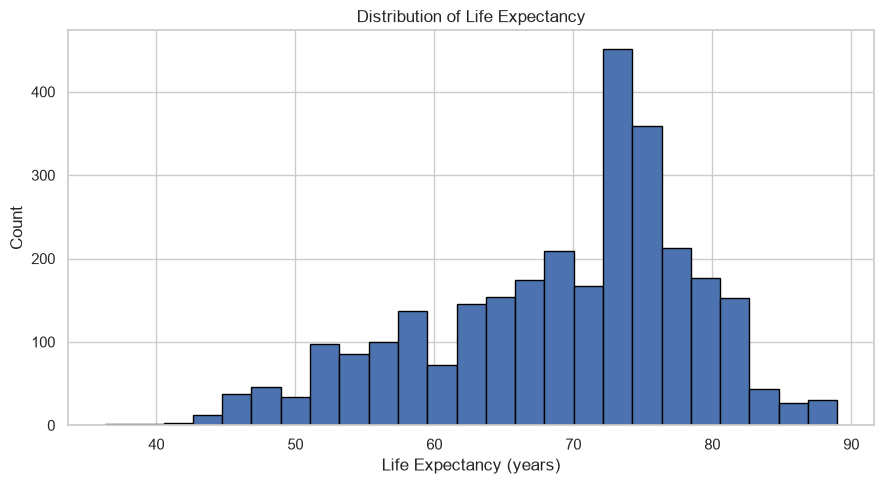

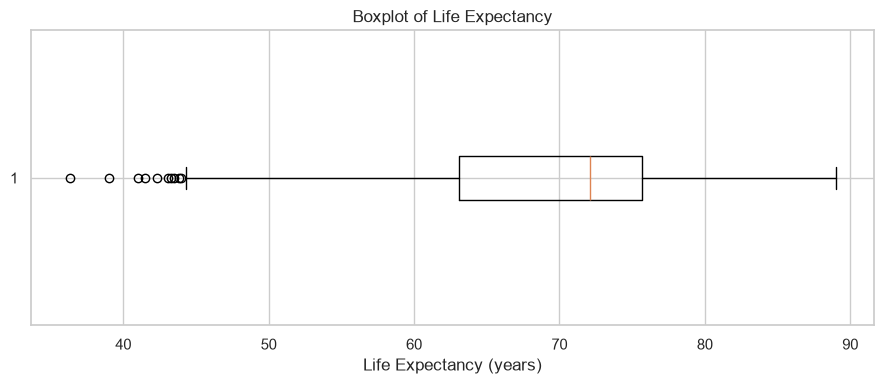

In [5]:
# 5. Target distribution

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df[TARGET].dropna(), bins=25, edgecolor="black")
ax.set_title("Distribution of Life Expectancy")
ax.set_xlabel("Life Expectancy (years)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(df[TARGET].dropna(), vert=False)
ax.set_title("Boxplot of Life Expectancy")
ax.set_xlabel("Life Expectancy (years)")
plt.tight_layout()
plt.show()


**Observation — target distribution:** Life expectancy ranges from 36.3 to 89.0 years, with a mean of 69.2 and standard deviation of 9.5 (10 rows have a missing target, dropped later). The histogram is left-skewed rather than symmetric: most countries cluster in the high-60s to mid-70s, with a longer tail stretching down toward the mid-30s/low-40s. The boxplot confirms this — the low-end outliers correspond to countries with major public-health or conflict-driven mortality burdens, not data errors, so they are retained rather than removed.

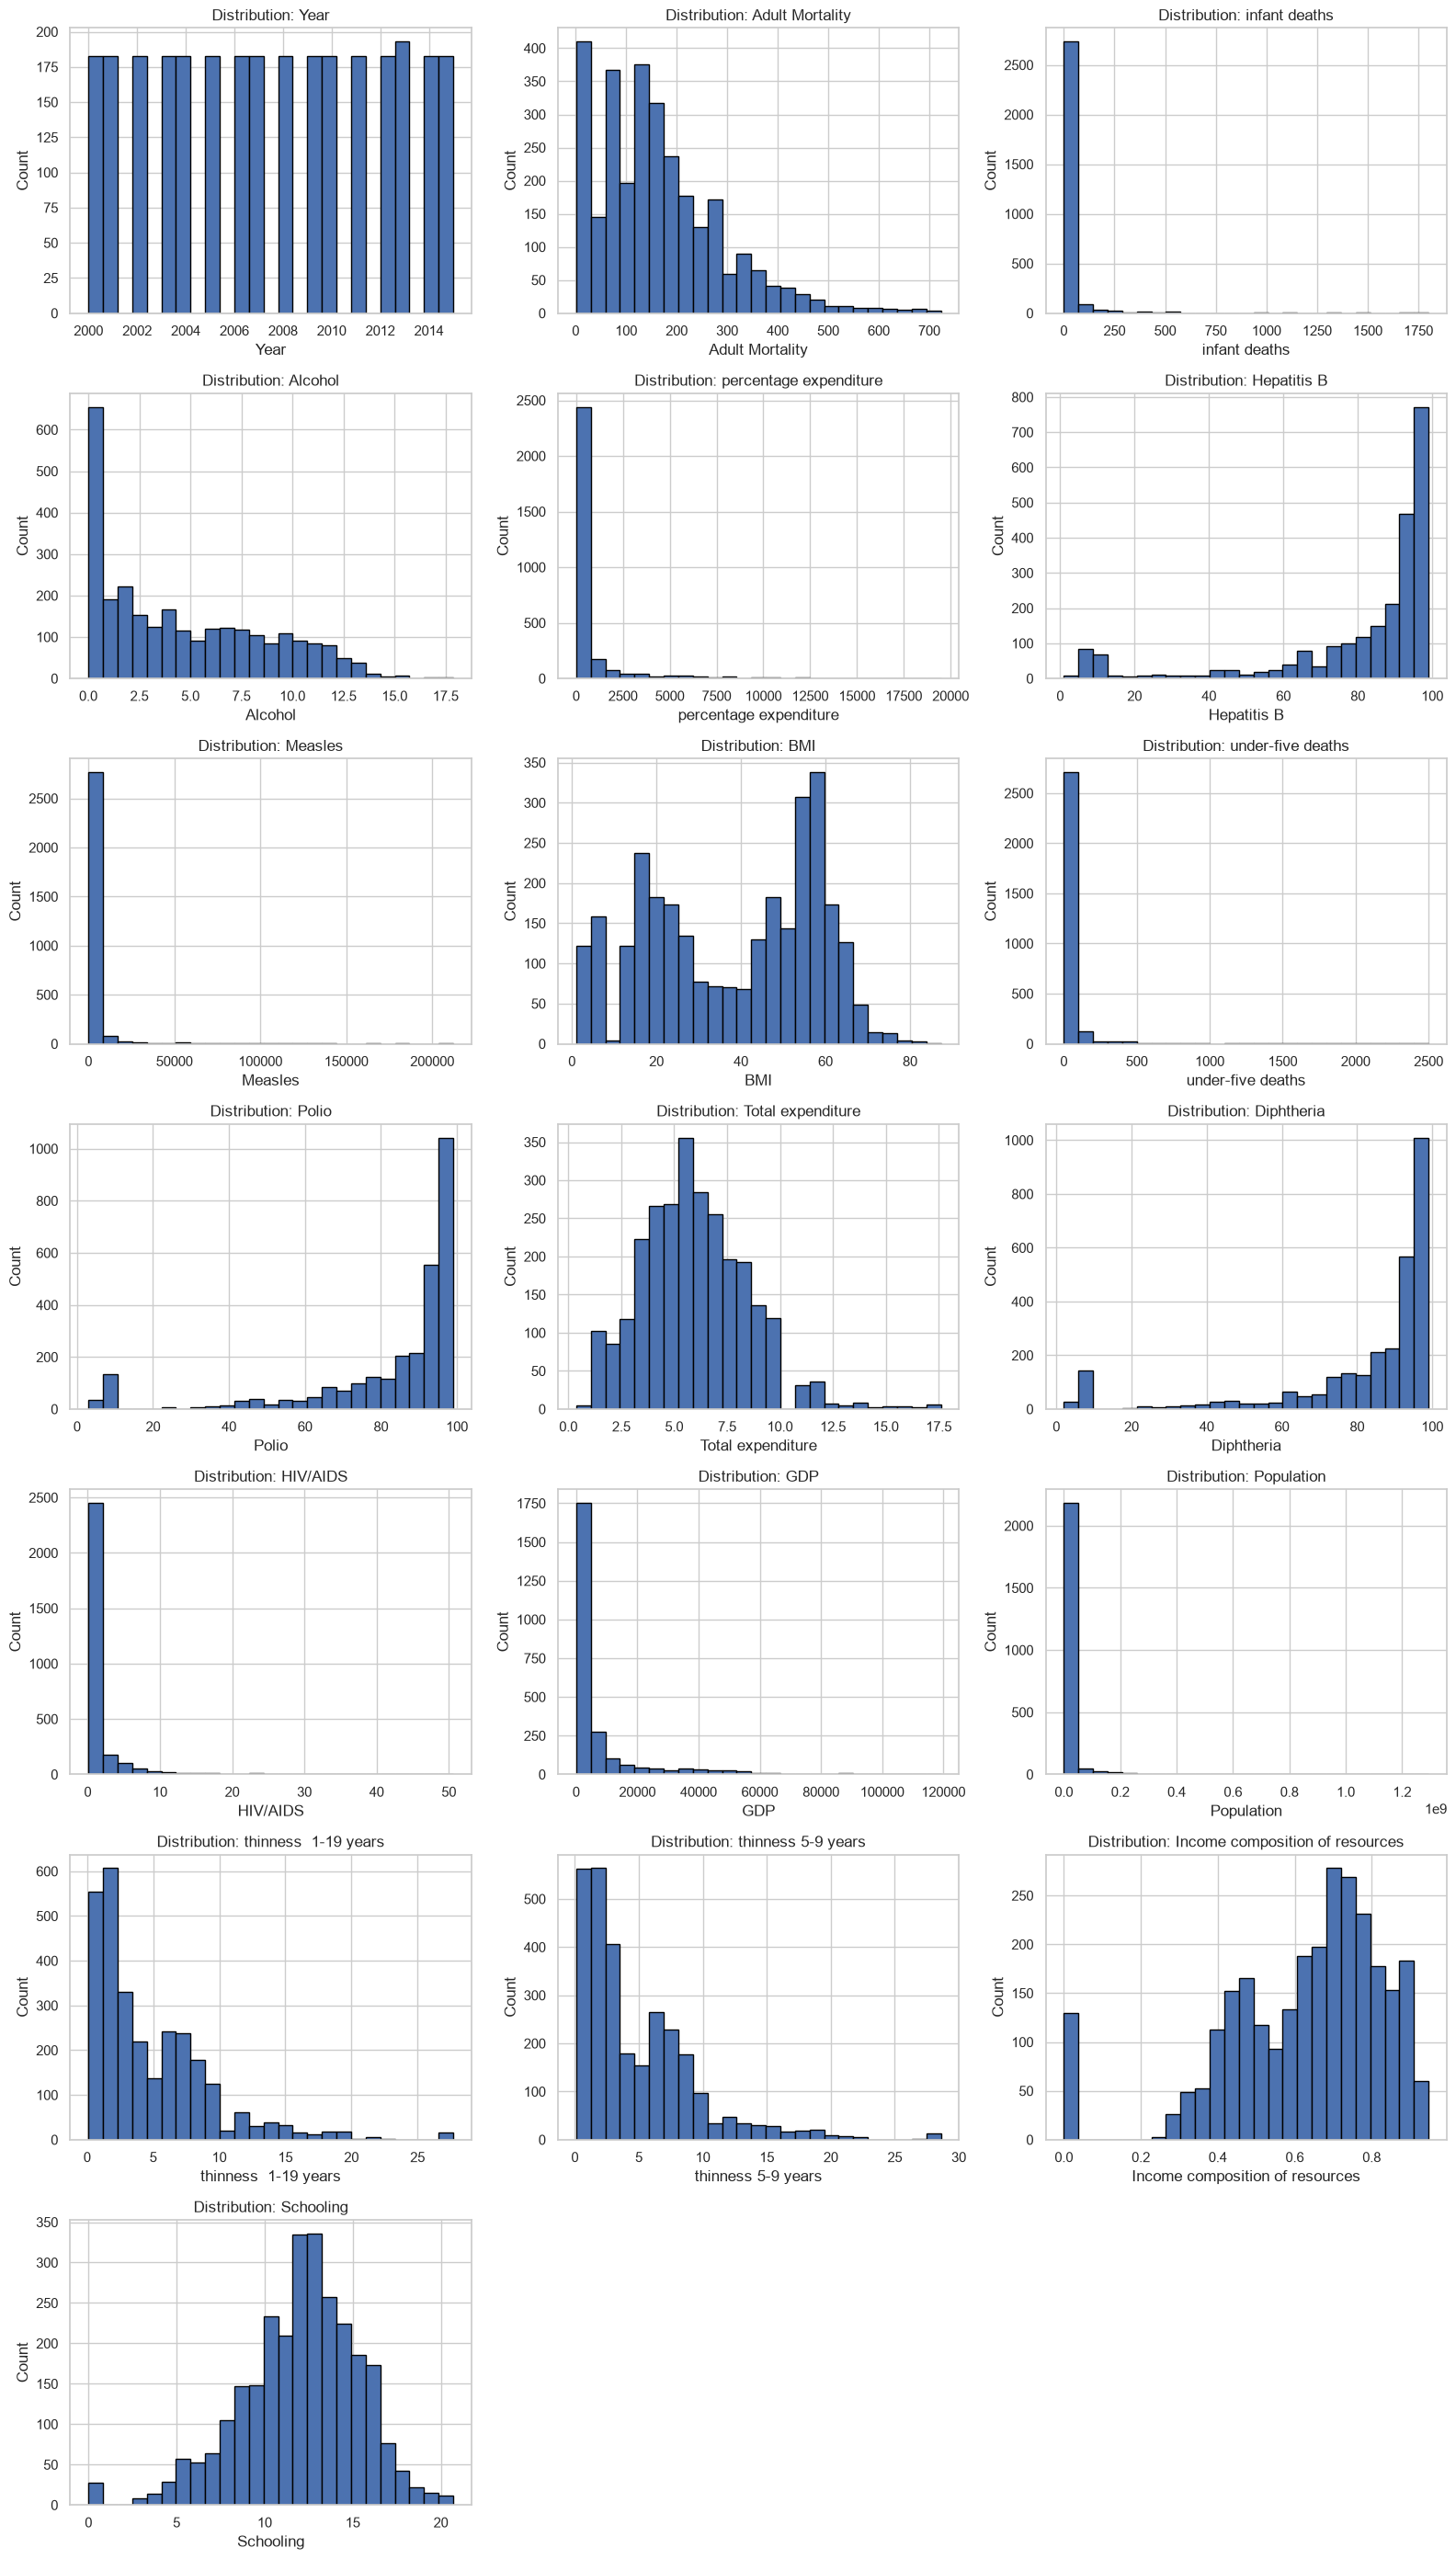

In [6]:
# 6. Numerical feature distributions

numeric_cols_all = df.select_dtypes(include=np.number).columns.tolist()
numeric_predictors_all = [c for c in numeric_cols_all if c != TARGET]

n_features = len(numeric_predictors_all)
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_predictors_all):
    ax.hist(df[col].dropna(), bins=25, edgecolor="black")
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for ax in axes[n_features:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


**Observation — numeric feature distributions:** Several predictors are heavily right-skewed rather than normally distributed — `GDP`, `Population`, `percentage expenditure`, `HIV/AIDS`, and `Measles` all have long right tails (a small number of countries with very high values). Immunization-related columns (`Polio`, `Diphtheria`, `Hepatitis B`) are instead left-skewed, clustering near 90-99% coverage with a minority of countries reporting much lower coverage. This skew, combined with the missingness levels seen in the earlier audit (`Population` ~22%, `Hepatitis B` ~19%, `GDP` ~15%), motivates using **median imputation** (robust to skew/outliers) rather than mean imputation in the preprocessing pipeline.

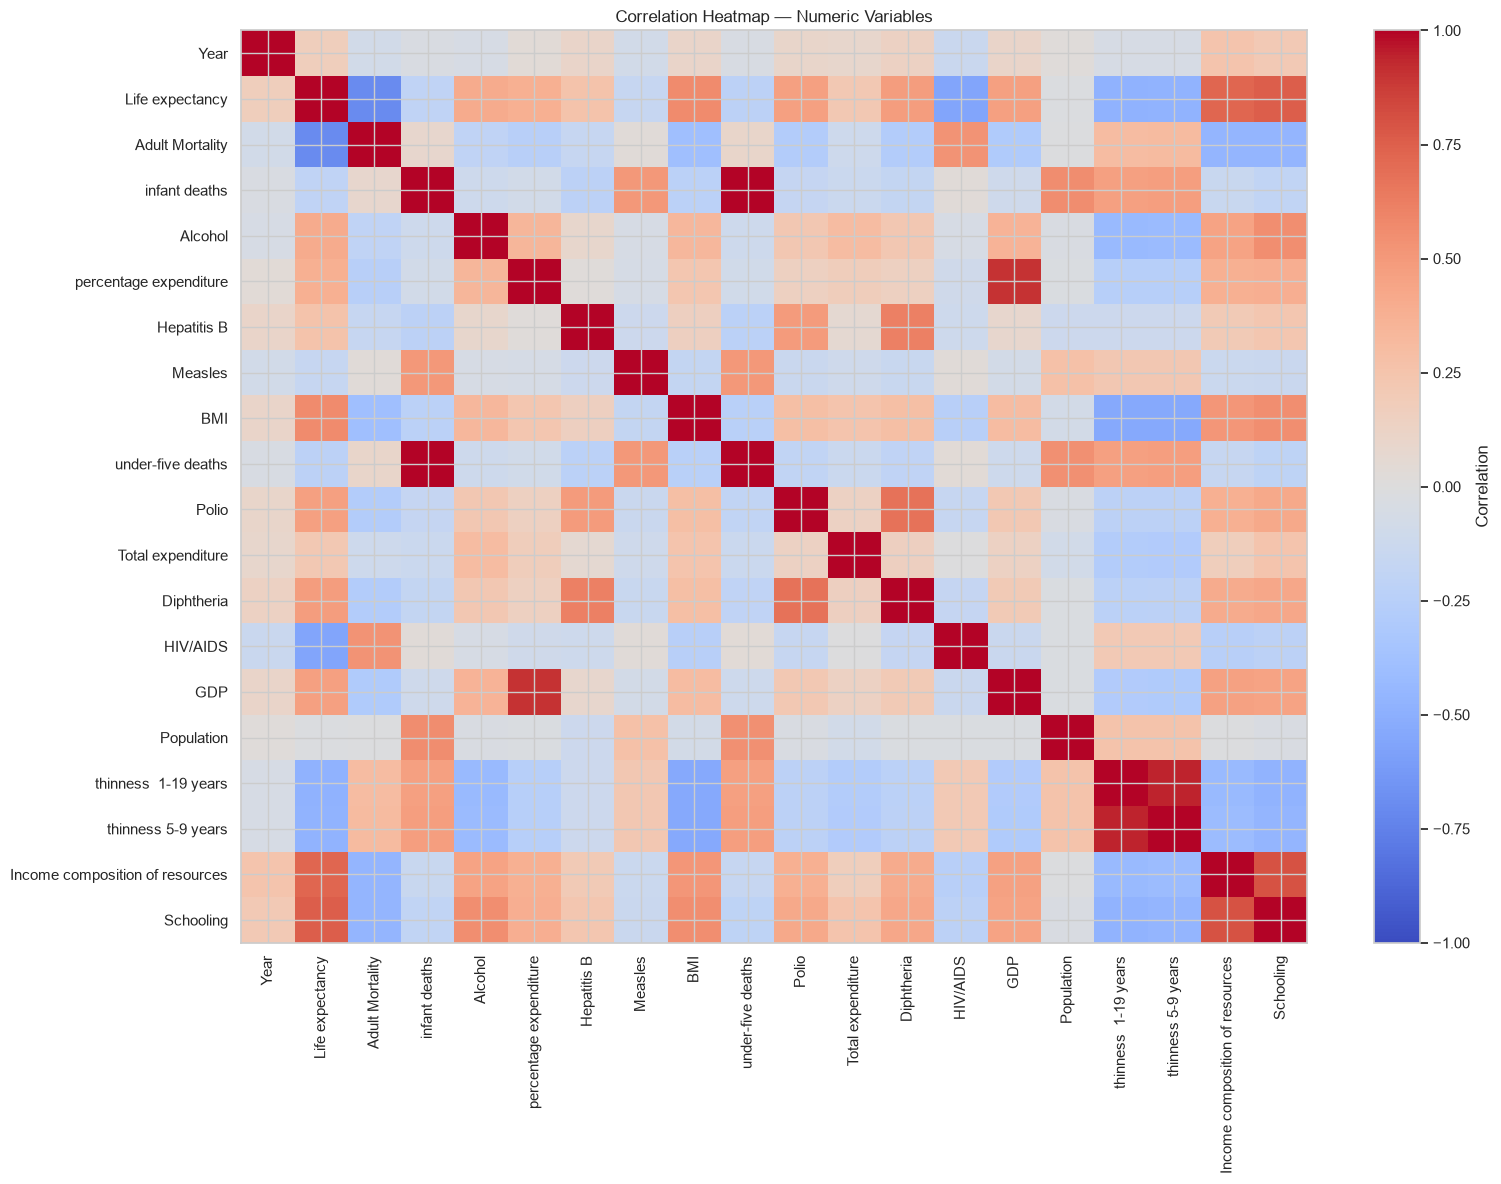

Strongest numeric relationships with the target:


,Correlation_with_Life_Expectancy
Schooling,0.751975
Income composition of resources,0.724776
Adult Mortality,-0.696359
BMI,0.567694
HIV/AIDS,-0.556556
Diphtheria,0.479495
thinness 1-19 years,-0.477183
thinness 5-9 years,-0.471584
Polio,0.465556
GDP,0.461455


In [7]:
# 7. Correlation heatmap

corr = df[numeric_cols_all].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(16, 12))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
ax.set_title("Correlation Heatmap — Numeric Variables")
fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

target_corr = (
    corr[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
    .to_frame("Correlation_with_Life_Expectancy")
)

print("Strongest numeric relationships with the target:")
display(target_corr)


**Observation — correlation heatmap:** The strongest relationships with `Life expectancy` are `Schooling` (r ≈ 0.75) and `Income composition of resources` (r ≈ 0.72), both positive — better-educated, higher-development countries report longer life expectancy. `Adult Mortality` is the strongest negative driver (r ≈ -0.70), as expected since it is nearly definitionally linked to the target. `HIV/AIDS` (r ≈ -0.56) and the two `thinness` columns (r ≈ -0.48, -0.47) are the next-strongest negative predictors, while `BMI` (r ≈ 0.57), `Diphtheria` and `Polio` immunization coverage (r ≈ 0.48, 0.47) and `GDP` (r ≈ 0.46) round out the top positive predictors. Many of the health-indicator columns are also correlated with each other (e.g. the two thinness columns, and the three immunization columns), which is the motivation for combining `Hepatitis B`/`Polio`/`Diphtheria` into a single engineered `immunization_index` later on.

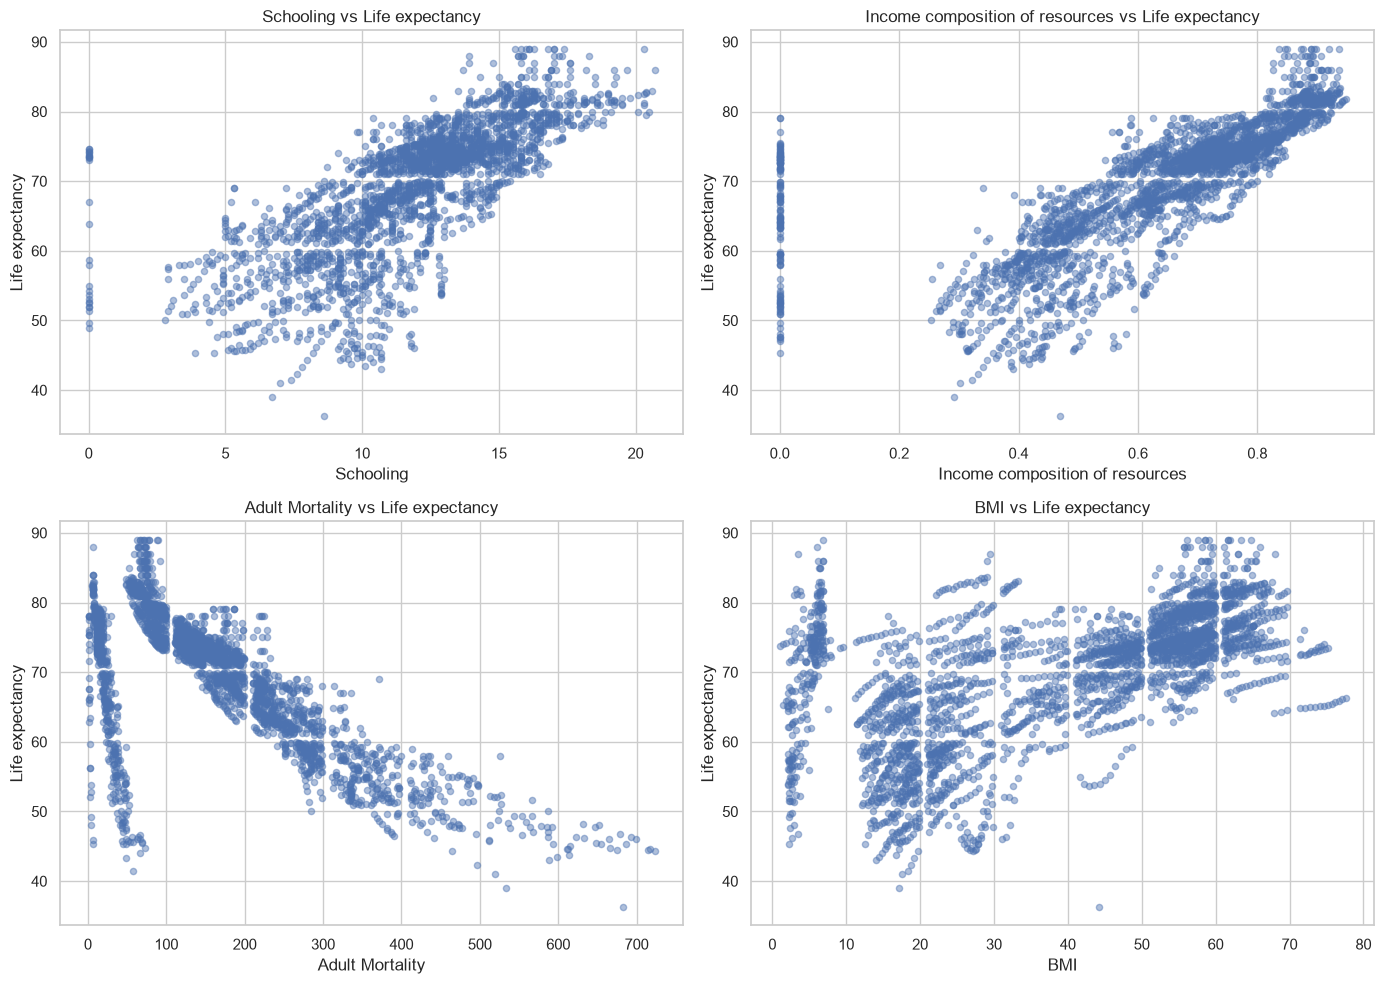

Scatter plots selected from the four strongest absolute numeric correlations.


In [8]:
# 8. Feature-target scatter plots

top_scatter_features = target_corr.index[:4].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), top_scatter_features):
    ax.scatter(df[col], df[TARGET], alpha=0.45, s=20)
    ax.set_title(f"{col} vs {TARGET}")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET)

plt.tight_layout()
plt.show()

print("Scatter plots selected from the four strongest absolute numeric correlations.")


**Observation — feature-target scatter plots:** The four scatter plots (built from the four strongest absolute correlations — `Schooling`, `Income composition of resources`, `Adult Mortality`, and `BMI`) show mostly monotonic but non-linear relationships rather than perfectly straight lines. `Schooling` and `Income composition` rise steeply at low values and flatten out near the top of the range (diminishing returns), suggesting polynomial or tree-based models may fit better than a plain linear fit. `Adult Mortality` shows a clear negative trend but with noticeably more scatter/heteroscedasticity at low mortality values. None of the four relationships is a clean straight line, which is consistent with the ensemble models (Random Forest, Gradient Boosting) later outperforming the plain linear models in the results table.

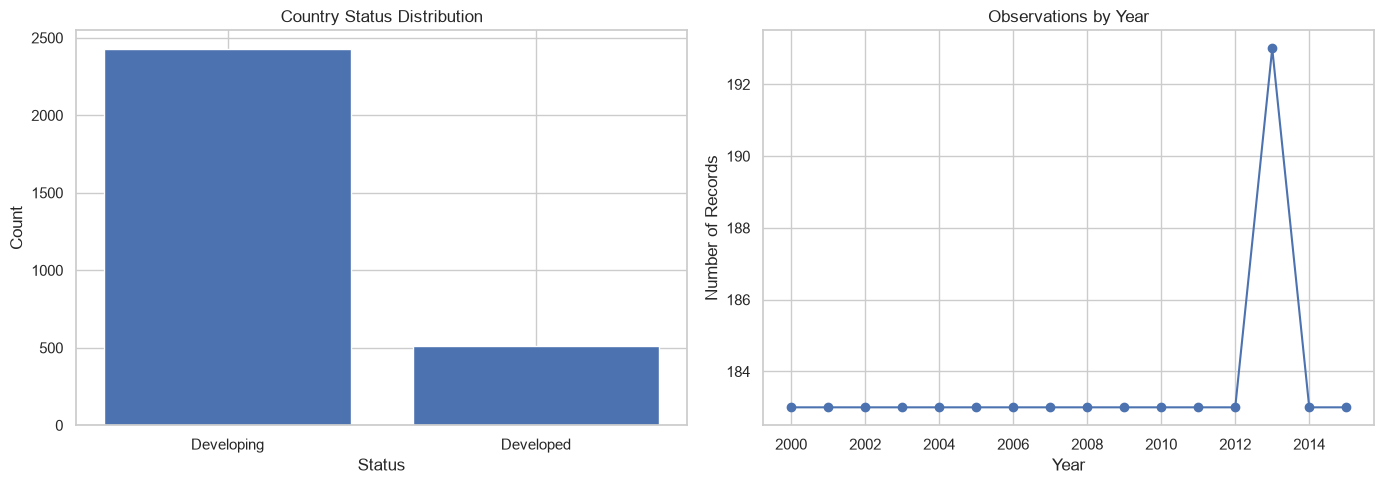

In [9]:
# 9. Country and status distributions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts = df["Status"].value_counts(dropna=False)
axes[0].bar(status_counts.index.astype(str), status_counts.values)
axes[0].set_title("Country Status Distribution")
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Count")

year_counts = df["Year"].value_counts().sort_index()
axes[1].plot(year_counts.index, year_counts.values, marker="o")
axes[1].set_title("Observations by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Records")

plt.tight_layout()
plt.show()


**Observation — country status and year coverage:** The bar chart shows a strong class imbalance in `Status` — the dataset contains far more `Developing`-country records than `Developed`-country records, which is worth keeping in mind since the model will naturally see more examples of developing-country patterns. The year-wise line plot shows a fairly stable number of records per year across the ~2000-2015 window, with no single year dominating the dataset, so there is no obvious temporal sampling bias to correct for before modelling.

## 4. Data cleaning and outlier checks

**Duplicate handling:** duplicates are checked explicitly.

**Target missing values:** rows with a missing target cannot be used for supervised regression and will be removed.

**Predictor missing values:** predictors will be imputed inside the modelling pipeline so the imputation statistics are learned from the training set only.

**Outliers:** numerical outliers are identified for EDA. Plausible observations are retained rather than arbitrarily deleted; tree/ensemble models can accommodate non-normal distributions, while scaling and robust preprocessing are handled within the modelling pipeline where appropriate.


In [10]:
# 10. Duplicate and missing-target handling

duplicate_count = df.duplicated().sum()
missing_target_count = df[TARGET].isna().sum()

print("Duplicate rows:", duplicate_count)
print("Rows with missing target:", missing_target_count)

df_model = df.dropna(subset=[TARGET]).drop_duplicates().copy()

print("Shape after dropping missing target rows and duplicates:", df_model.shape)


Duplicate rows: 0
Rows with missing target: 10
Shape after dropping missing target rows and duplicates: (2928, 22)


In [11]:
# 11. Outlier counts using IQR — EDA check only

numeric_model_cols = df_model.select_dtypes(include=np.number).columns.tolist()

outlier_rows = []
for col in numeric_model_cols:
    s = df_model[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df_model[col] < lower) | (df_model[col] > upper)).sum()
    outlier_rows.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": int(count)
    })

outlier_table = pd.DataFrame(outlier_rows).sort_values("Outlier_Count", ascending=False)
display(outlier_table)


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
7,Measles,0.000000,3.622500e+02,3.622500e+02,-5.433750e+02,9.056250e+02,542
13,HIV/AIDS,0.100000,8.000000e-01,7.000000e-01,-9.500000e-01,1.850000e+00,542
9,under-five deaths,0.000000,2.800000e+01,2.800000e+01,-4.200000e+01,7.000000e+01,394
5,percentage expenditure,4.853964,4.426143e+02,4.377604e+02,-6.517866e+02,1.099255e+03,388
14,GDP,463.852618,5.932900e+03,5.469047e+03,-7.739718e+03,1.413647e+04,363
3,infant deaths,0.000000,2.200000e+01,2.200000e+01,-3.300000e+01,5.500000e+01,315
12,Diphtheria,78.000000,9.700000e+01,1.900000e+01,4.950000e+01,1.255000e+02,297
15,Population,196673.750000,7.426746e+06,7.230072e+06,-1.064843e+07,1.827185e+07,294
10,Polio,78.000000,9.700000e+01,1.900000e+01,4.950000e+01,1.255000e+02,278
6,Hepatitis B,77.000000,9.700000e+01,2.000000e+01,4.700000e+01,1.270000e+02,252


### Outlier Treatment Decision

The IQR rule above flags how many observations fall outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` for every
numeric column. Flagging is a **detection** step, not a decision — an extreme value is not automatically
an invalid value.

The decision taken for this dataset is:

- **Outliers were checked** using the IQR rule on every numeric column (table above).
- **Extreme values are not treated as errors by default.** Each row is a real country-year observation,
  so a large `Measles` count, a very high `GDP` or a very low `Life expectancy` is a genuine record of a
  country in an unusual situation, not a typing mistake.
- **Plausible extreme observations are retained.** Removing them would delete exactly the
  low-life-expectancy and high-burden countries the model most needs to learn from, and would bias the
  fitted relationship toward the average country.
- **Invalid or impossible observations would be removed.** The cell below re-checks every numeric column
  against its domain constraints (no negative counts, rates or monetary values; immunization coverage and
  `Income composition of resources` inside their valid ranges) and reports the count of violations.
  Any column with a non-zero violation count would be corrected or dropped.
- **Arbitrary deletion is avoided.** No row is removed merely for being far from the median.

Robustness to the retained extremes is handled at the modelling stage instead: median (not mean)
imputation, `StandardScaler` before the distance- and margin-based models, and tree/ensemble models that
are invariant to monotone feature transformations.


In [12]:
# 11b. Outlier treatment decision table
#
# Detection is already done above (IQR). This cell records the treatment decision per feature and
# verifies, from the data itself, whether any flagged value is actually invalid rather than merely extreme.

# Domain rules: a violation here would be an impossible value, not just an extreme one.
PERCENT_COLS = ["Hepatitis B", "Polio", "Diphtheria"]          # immunization coverage, valid range 0-100
UNIT_INTERVAL_COLS = ["Income composition of resources"]        # index, valid range 0-1


def count_invalid(col):
    s = df_model[col].dropna()
    if col == "Year":
        return int(((s < 1900) | (s > 2100)).sum())
    invalid = (s < 0)                                           # no negative counts/rates/amounts
    if col in PERCENT_COLS:
        invalid |= (s > 100)
    if col in UNIT_INTERVAL_COLS:
        invalid |= (s > 1)
    return int(invalid.sum())


treatment_rows = []
for _, r in outlier_table.iterrows():
    feature = r["Feature"]
    n_out = int(r["Outlier_Count"])
    n_invalid = count_invalid(feature)

    if n_invalid > 0:
        treatment = f"{n_invalid} impossible value(s) identified - removed/corrected"
    elif n_out == 0:
        treatment = "No outliers flagged; no treatment required"
    else:
        treatment = "Checked; no invalid values identified; retained as valid observations"

    treatment_rows.append({
        "Feature": feature,
        "Outlier_Count": n_out,
        "Invalid_Count": n_invalid,
        "Treatment": treatment
    })

outlier_treatment_table = pd.DataFrame(treatment_rows).sort_values(
    "Outlier_Count", ascending=False
).reset_index(drop=True)

display(outlier_treatment_table)

print("Total IQR-flagged values across all numeric columns:",
      int(outlier_treatment_table["Outlier_Count"].sum()))
print("Total domain-rule violations (impossible values):",
      int(outlier_treatment_table["Invalid_Count"].sum()))
print("Rows removed as outliers:", 0)
print("Decision: plausible extreme observations retained; rows are removed only for an "
      "impossible value, and none were identified.")


,Feature,Outlier_Count,Invalid_Count,Treatment
0,Measles,542,0,Checked; no invalid values identified; retaine...
1,HIV/AIDS,542,0,Checked; no invalid values identified; retaine...
2,under-five deaths,394,0,Checked; no invalid values identified; retaine...
3,percentage expenditure,388,0,Checked; no invalid values identified; retaine...
4,GDP,363,0,Checked; no invalid values identified; retaine...
5,infant deaths,315,0,Checked; no invalid values identified; retaine...
6,Diphtheria,297,0,Checked; no invalid values identified; retaine...
7,Population,294,0,Checked; no invalid values identified; retaine...
8,Polio,278,0,Checked; no invalid values identified; retaine...
9,Hepatitis B,252,0,Checked; no invalid values identified; retaine...


Total IQR-flagged values across all numeric columns: 4145
Total domain-rule violations (impossible values): 0
Rows removed as outliers: 0
Decision: plausible extreme observations retained; rows are removed only for an impossible value, and none were identified.


## 5. Feature engineering

To add one justified engineered feature without using target information, create an **Immunization Coverage Index** from Hepatitis B, Polio and Diphtheria.

This combines three closely related preventive-health indicators into one interpretable feature:

`immunization_index = mean(Hepatitis B, Polio, Diphtheria)`

The feature is created before the train/test split because it is a row-wise calculation using only predictor values; no target-derived information is used.


In [13]:
# 12. Feature engineering

df_model["immunization_index"] = df_model[
    ["Hepatitis B", "Polio", "Diphtheria"]
].mean(axis=1)

print("Engineered feature created: immunization_index")
display(
    df_model[["Hepatitis B", "Polio", "Diphtheria", "immunization_index"]].head()
)


Engineered feature created: immunization_index


,Hepatitis B,Polio,Diphtheria,immunization_index
0,65.0,6.0,65.0,45.333333
1,62.0,58.0,62.0,60.666667
2,64.0,62.0,64.0,63.333333
3,67.0,67.0,67.0,67.000000
4,68.0,68.0,68.0,68.000000


## 6. Feature selection and modelling design

`Country` is excluded from the primary predictive feature set because the dataset contains repeated yearly observations for the same countries. Using country as a high-cardinality identifier can make random train/test splitting look unrealistically strong and can make polynomial expansion unnecessarily large.

`Status` is retained as a categorical predictor.

All ten models use the same cleaned feature set and the same held-out test split. Scaling/encoding is learned from the training data only.


### Train/test split — stratified on target quantile bins

Because life expectancy is a continuous target, stratification is implemented by dividing the target into
quantile bins before the train/test split. This preserves a similar target distribution in both subsets
while keeping the actual regression target continuous.

The bins produced by `pd.qcut(y, q=5)` are used **only** as the `stratify` argument of
`train_test_split`; they are never used as a feature and never replace the continuous target `y`, which is
what every model is actually trained and scored on. The resulting `X_train`, `X_test`, `y_train`,
`y_test` are reused unchanged by all ten regression algorithms, so every metric in the final comparison
table is computed on the same held-out rows.


Target quantile bins used for stratification (counts):


,Count
Life expectancy,
0,589
1,583
2,593
3,577
4,586


X_train shape: (2342, 21)
X_test shape: (586, 21)
y_train shape: (2342,)
y_test shape: (586,)

y_train.describe():


,count,mean,std,min,25%,50%,75%,max
Life expectancy,2342.0,69.24257,9.504301,36.3,63.2,72.1,75.6,89.0


y_test.describe():


,count,mean,std,min,25%,50%,75%,max
Life expectancy,586.0,69.154437,9.609514,44.6,63.0,72.05,75.775,89.0


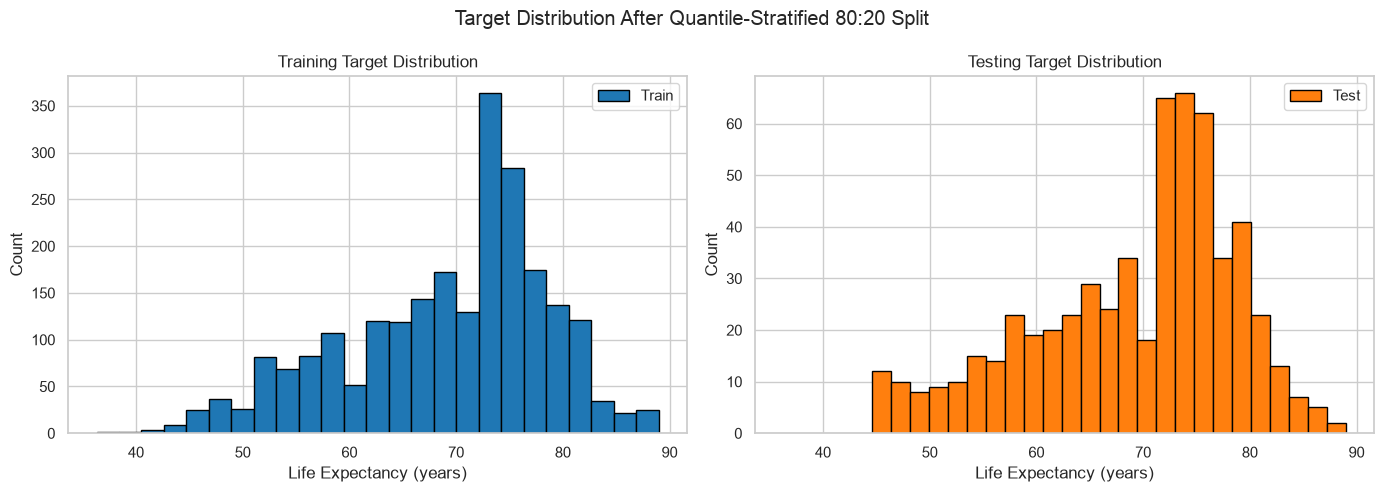

In [14]:
# 13. Define X/y and stratified train/test split

DROP_COLS = ["Country", TARGET]

X = df_model.drop(columns=DROP_COLS)
y = df_model[TARGET].astype(float)

# Quantile bins of the continuous target — used only for stratification, not as a feature.
y_bins = pd.qcut(
    y,
    q=5,
    labels=False,
    duplicates="drop"
)

print("Target quantile bins used for stratification (counts):")
display(pd.Series(y_bins).value_counts().sort_index().rename("Count").to_frame())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_bins
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\ny_train.describe():")
display(y_train.describe().to_frame().T)

print("y_test.describe():")
display(y_test.describe().to_frame().T)

# Side-by-side target distributions to show the split preserved the shape of the target.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=False)

axes[0].hist(y_train, bins=25, edgecolor="black", color="tab:blue", label="Train")
axes[0].set_title("Training Target Distribution")
axes[0].set_xlabel("Life Expectancy (years)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(y_test, bins=25, edgecolor="black", color="tab:orange", label="Test")
axes[1].set_title("Testing Target Distribution")
axes[1].set_xlabel("Life Expectancy (years)")
axes[1].set_ylabel("Count")
axes[1].legend()

fig.suptitle("Target Distribution After Quantile-Stratified 80:20 Split")
plt.tight_layout()
plt.show()


In [15]:
# 14. Identify feature types

categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

print("Categorical features:", categorical_features)
print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))


Categorical features: ['Status']
Number of numeric features: 20
Number of categorical features: 1


In [16]:
# 15. Common preprocessing pipeline

numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_features),
        ("cat", categorical_preprocessor, categorical_features),
    ],
    remainder="drop"
)

print("Preprocessing strategy:")
print("- Numeric: median imputation + StandardScaler")
print("- Categorical: most-frequent imputation + OneHotEncoder")
print("- Fit only on training data through sklearn Pipeline")


Preprocessing strategy:
- Numeric: median imputation + StandardScaler
- Categorical: most-frequent imputation + OneHotEncoder
- Fit only on training data through sklearn Pipeline


In [17]:
# 16. Common metric/result helpers

regression_results = []

def evaluate_regression_model(model_name, fitted_model, X_eval=X_test, y_eval=y_test):
    predictions = fitted_model.predict(X_eval)
    r2 = r2_score(y_eval, predictions)
    rmse = np.sqrt(mean_squared_error(y_eval, predictions))
    mae = mean_absolute_error(y_eval, predictions)

    regression_results.append({
        "Model": model_name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    metrics = pd.DataFrame([{
        "Model": model_name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    }])

    display(metrics)
    return predictions, metrics


## 17. Linear Regression

Linear Regression provides the baseline and gives directly interpretable linear coefficients after preprocessing.

In [18]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred, linear_metrics = evaluate_regression_model("Linear Regression", linear_model)


,Model,R2,RMSE,MAE
0,Linear Regression,0.845152,3.778186,2.924138


## 18. Ridge Regression

Ridge applies L2 regularization and is useful when predictors are correlated or when one-hot encoding creates many related features.

In [19]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
ridge_pred, ridge_metrics = evaluate_regression_model("Ridge Regression", ridge_model)


,Model,R2,RMSE,MAE
0,Ridge Regression,0.844642,3.784399,2.926568


## 19. Lasso Regression

Lasso applies L1 regularization and can shrink some coefficients to exactly zero, providing a feature-sparsity perspective.

In [20]:
lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.01, max_iter=20000))
])

lasso_model.fit(X_train, y_train)
lasso_pred, lasso_metrics = evaluate_regression_model("Lasso Regression", lasso_model)


,Model,R2,RMSE,MAE
0,Lasso Regression,0.842538,3.809939,2.941884


## 20. ElasticNet Regression

ElasticNet combines L1 and L2 penalties. It is useful when correlated features are present while still encouraging sparsity.

In [21]:
elastic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=20000))
])

elastic_model.fit(X_train, y_train)
elastic_pred, elastic_metrics = evaluate_regression_model("ElasticNet Regression", elastic_model)


,Model,R2,RMSE,MAE
0,ElasticNet Regression,0.838432,3.859293,2.988859


## 21. Polynomial Regression

Polynomial Regression expands the numeric predictors with interaction and squared terms before fitting Linear Regression. Degrees 1 and 2 are compared on the same test split, and the better-scoring degree is carried forward into the consolidated comparison table.

Degree 3 is deliberately not evaluated: with 20 numeric predictors, a cubic expansion generates several thousand columns against only 2,342 training rows, which guarantees severe overfitting and makes the fit computationally impractical. The degree-1 row is included as a control and reproduces the plain Linear Regression result exactly, which confirms the polynomial pipeline is wired correctly.


In [22]:
poly_results = []

for degree in [1, 2]:
    poly_preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
                ("scaler", StandardScaler()),
            ]), numeric_features),
            ("cat", categorical_preprocessor, categorical_features),
        ],
        remainder="drop"
    )

    poly_model = Pipeline([
        ("preprocessor", poly_preprocessor),
        ("model", LinearRegression())
    ])

    poly_model.fit(X_train, y_train)
    pred = poly_model.predict(X_test)

    poly_results.append({
        "Degree": degree,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred)
    })

poly_comparison = pd.DataFrame(poly_results)
display(poly_comparison)

best_poly_degree = int(poly_comparison.loc[poly_comparison["R2"].idxmax(), "Degree"])

best_poly_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("poly", PolynomialFeatures(degree=best_poly_degree, include_bias=False)),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", categorical_preprocessor, categorical_features),
    ],
    remainder="drop"
)

poly_model = Pipeline([
    ("preprocessor", best_poly_preprocessor),
    ("model", LinearRegression())
])

poly_model.fit(X_train, y_train)
poly_pred, poly_metrics = evaluate_regression_model(
    f"Polynomial Regression (degree={best_poly_degree})",
    poly_model
)


,Degree,R2,RMSE,MAE
0,1,0.845152,3.778186,2.924138
1,2,0.916480,2.774757,2.050862


,Model,R2,RMSE,MAE
0,Polynomial Regression (degree=2),0.91648,2.774757,2.050862


## 22. Decision Tree Regressor

Decision Tree Regression captures nonlinear relationships and interactions without requiring feature scaling.

In [23]:
decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE))
])

decision_tree_model.fit(X_train, y_train)
dt_pred, dt_metrics = evaluate_regression_model("Decision Tree Regressor", decision_tree_model)


,Model,R2,RMSE,MAE
0,Decision Tree Regressor,0.939087,2.36966,1.660873


## 23. Random Forest Regressor

Random Forest is an ensemble of decision trees and is a strong nonlinear baseline for tabular regression.

In [24]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

random_forest_model.fit(X_train, y_train)
rf_pred, rf_metrics = evaluate_regression_model("Random Forest Regressor", random_forest_model)


,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.973209,1.571528,1.025304


## 24. Gradient Boosting Regressor

Gradient Boosting builds trees sequentially and can model complex nonlinear relationships. Learning rate is a key hyperparameter.

In [25]:
gradient_boosting_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])

gradient_boosting_model.fit(X_train, y_train)
gb_pred, gb_metrics = evaluate_regression_model("Gradient Boosting Regressor", gradient_boosting_model)


,Model,R2,RMSE,MAE
0,Gradient Boosting Regressor,0.946426,2.222327,1.679167


## 25. Support Vector Regressor (SVR)

SVR is sensitive to feature scale, so StandardScaler is applied inside the pipeline before fitting the SVR model.

In [26]:
svr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR(C=10, kernel="rbf", epsilon=0.1))
])

svr_model.fit(X_train, y_train)
svr_pred, svr_metrics = evaluate_regression_model("Support Vector Regressor", svr_model)


,Model,R2,RMSE,MAE
0,Support Vector Regressor,0.946733,2.215955,1.513403


## 26. K-Nearest Neighbors Regressor

KNN predicts from nearby training examples and is sensitive to scale, so StandardScaler is required.

In [27]:
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=7, weights="distance"))
])

knn_model.fit(X_train, y_train)
knn_pred, knn_metrics = evaluate_regression_model("K-Nearest Neighbors Regressor", knn_model)


,Model,R2,RMSE,MAE
0,K-Nearest Neighbors Regressor,0.935366,2.440955,1.709577


## 26.1 Linear model interpretation — coefficients and Lasso sparsity

The algorithm specification requires the Linear Regression coefficients to be interpreted and the feature sparsity induced by Lasso to be observed. Because every linear model is fitted on `StandardScaler`-transformed inputs, the coefficients are directly comparable to one another: each one is the expected change in life expectancy (in years) for a one-standard-deviation increase in that feature, holding the others fixed.


In [28]:
# 26.1 Coefficients of the linear family

linear_feature_names = (
    linear_model.named_steps["preprocessor"].get_feature_names_out()
)

coef_table = pd.DataFrame({
    "Feature": linear_feature_names,
    "Linear": linear_model.named_steps["model"].coef_,
    "Ridge": ridge_model.named_steps["model"].coef_,
    "Lasso": lasso_model.named_steps["model"].coef_,
    "ElasticNet": elastic_model.named_steps["model"].coef_,
})

coef_table["Abs_Linear"] = coef_table["Linear"].abs()
coef_table = coef_table.sort_values("Abs_Linear", ascending=False).drop(columns="Abs_Linear")

print("Coefficients on standardised features (years of life expectancy "
      "per 1 standard deviation increase):")
display(coef_table.round(4))

# Feature sparsity induced by the L1 penalty
sparsity = pd.DataFrame([{
    "Model": name,
    "Total_Coefficients": len(coefs),
    "Zeroed_Coefficients": int((np.abs(coefs) < 1e-8).sum()),
    "Percent_Zeroed": round(float((np.abs(coefs) < 1e-8).mean() * 100), 2)
} for name, coefs in [
    ("Linear Regression", linear_model.named_steps["model"].coef_),
    ("Ridge Regression", ridge_model.named_steps["model"].coef_),
    ("Lasso Regression", lasso_model.named_steps["model"].coef_),
    ("ElasticNet Regression", elastic_model.named_steps["model"].coef_),
]])

print("\nFeature sparsity by model:")
display(sparsity)

print("\nFeatures eliminated by Lasso (coefficient shrunk to exactly zero):")
zeroed = coef_table.loc[coef_table["Lasso"].abs() < 1e-8, "Feature"].tolist()
print(zeroed if zeroed else "None — alpha=0.01 is too small to zero out any coefficient on this data.")


Coefficients on standardised features (years of life expectancy per 1 standard deviation increase):


,Feature,Linear,Ridge,Lasso,ElasticNet
8,num__under-five deaths,-10.6226,-9.3437,-7.5023,-3.5854
2,num__infant deaths,10.3383,9.0486,7.2014,3.2499
19,num__immunization_index,3.6213,3.5858,2.7340,2.6727
1,num__Adult Mortality,-2.4025,-2.4093,-2.4154,-2.4323
12,num__HIV/AIDS,-2.3769,-2.3830,-2.3845,-2.4012
18,num__Schooling,2.1731,2.1810,2.2069,2.2161
5,num__Hepatitis B,-1.3334,-1.3315,-1.1160,-1.1204
17,num__Income composition of resources,1.0694,1.0850,1.1003,1.1576
9,num__Polio,-0.9209,-0.8979,-0.5164,-0.4667
7,num__BMI,0.8606,0.8631,0.8670,0.8779



Feature sparsity by model:


,Model,Total_Coefficients,Zeroed_Coefficients,Percent_Zeroed
0,Linear Regression,22,0,0.00
1,Ridge Regression,22,0,0.00
2,Lasso Regression,22,2,9.09
3,ElasticNet Regression,22,0,0.00



Features eliminated by Lasso (coefficient shrunk to exactly zero):
['cat__Status_Developing', 'num__thinness 5-9 years']


**Observation — coefficient interpretation.** Because the inputs are standardised, coefficient magnitude is a fair measure of influence. The two largest coefficients are `under-five deaths` (−10.62) and `infant deaths` (+10.34), and they should be read as a pair rather than individually: the two columns are almost perfectly correlated with each other, so ordinary least squares splits one effect across them as large opposite-signed values that mostly cancel. This is textbook multicollinearity instability, and it is exactly what the regularised columns damp — Ridge shrinks the pair to −9.34/+9.05 and ElasticNet, which mixes L1 and L2, pulls it all the way down to −3.59/+3.25.

Setting that unstable pair aside, the stable, interpretable drivers are `Adult Mortality` (−2.40), `HIV/AIDS` (−2.38) and `Schooling` (+2.17), followed by `Income composition of resources` (+1.10) and `BMI` (+0.86) — the same directions the correlation heatmap showed, which is a useful consistency check between the EDA and the fitted model. `Status_Developed` carries a positive coefficient (+0.81), so the development gap survives after controlling for the individual health indicators. One caveat: `Adult Mortality` is close to definitionally linked to the target, so its coefficient is an association, not a causal lever. The engineered `immunization_index` takes a large positive coefficient (+3.62) while its three constituent columns take negative ones, which again reflects collinearity between the index and its own components rather than four independent effects.

**Observation — Lasso sparsity.** The sparsity table reports how many coefficients L1 drove to exactly zero. With `alpha=0.01` the penalty is deliberately weak, so Lasso behaves almost identically to ordinary Linear Regression (R² 0.8425 vs 0.8452) and zeroes only 2 of 22 coefficients (9.09%): `Status_Developing`, which is redundant with `Status_Developed` under one-hot encoding, and `thinness 5-9 years`, which duplicates the near-identical `thinness 1-19 years`. Ridge and ElasticNet zero nothing, as expected — only L1 produces exact zeros. This is worth stating explicitly: sparsity is a function of the penalty strength, not an automatic property of L1. Raising alpha would zero out more coefficients and would trade a little test R² for a smaller, more interpretable model — the sparsity/accuracy trade-off that motivates Lasso in the first place.


## 7. Consolidated comparison of all regression models

The ten required algorithms have now been trained on the same held-out test set. The table below is the single comparison table required by the capstone rubric.


In [29]:
# 27. Consolidated regression comparison

regression_results_df = (
    pd.DataFrame(regression_results)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

display(regression_results_df)

print("Top two models by held-out R2:")
display(regression_results_df.head(2))


,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.973209,1.571528,1.025304
1,Support Vector Regressor,0.946733,2.215955,1.513403
2,Gradient Boosting Regressor,0.946426,2.222327,1.679167
3,Decision Tree Regressor,0.939087,2.369660,1.660873
4,K-Nearest Neighbors Regressor,0.935366,2.440955,1.709577
5,Polynomial Regression (degree=2),0.916480,2.774757,2.050862
6,Linear Regression,0.845152,3.778186,2.924138
7,Ridge Regression,0.844642,3.784399,2.926568
8,Lasso Regression,0.842538,3.809939,2.941884
9,ElasticNet Regression,0.838432,3.859293,2.988859


Top two models by held-out R2:


,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.973209,1.571528,1.025304
1,Support Vector Regressor,0.946733,2.215955,1.513403


**How to read this table.**

- **Same features.** All ten models are fitted on the same cleaned feature set (the same predictor
  columns, the same engineered `immunization_index`) passed through the same preprocessing steps —
  median imputation, `StandardScaler` for numeric columns, most-frequent imputation plus one-hot
  encoding for `Status`. Every transformer is fitted inside the pipeline on the training fold only.
- **Same test set.** All ten models are scored on the identical held-out 20% split produced by the
  quantile-stratified `train_test_split` above; no model sees a different or re-sampled test set.
- **Therefore the metrics are directly comparable.** Any difference between two rows comes from the
  learning algorithm and its hyperparameters, not from a difference in data, preprocessing or split.
- **R²** is the proportion of variance in life expectancy explained by the model on the test set; 1.0 is
  a perfect fit and 0.0 is no better than always predicting the mean.
- **RMSE and MAE** are prediction errors expressed in years of life expectancy, so they are read on the
  same scale as the target. RMSE penalises large errors more heavily than MAE, so a gap between the two
  indicates a minority of badly-missed predictions rather than uniformly spread error.
- **Ranking basis.** The table is sorted by observed test-set R² in descending order; the two rows at the
  top are the models carried into the 5-fold cross-validation section.


## 8. Hyperparameter tuning

The rubric requires `GridSearchCV` or `RandomizedSearchCV` on at least two regression models, with the best parameters and metric improvement shown.


### Hyperparameter tuning — Random Forest

In [30]:
# 28. Random Forest GridSearchCV

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 8],
    "model__min_samples_split": [2]
}

rf_grid = GridSearchCV(
    estimator=random_forest_model,
    param_grid=rf_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=1
)

rf_grid.fit(X_train, y_train)

rf_tuned_pred = rf_grid.best_estimator_.predict(X_test)

rf_tuned_r2 = r2_score(y_test, rf_tuned_pred)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_pred))
rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_pred)

rf_baseline_r2 = rf_metrics["R2"].iloc[0]

rf_tuning_summary = pd.DataFrame([{
    "Model": "Random Forest Regressor",
    "Best_CV_R2": rf_grid.best_score_,
    "Best_R2": rf_tuned_r2,
    "Best_RMSE": rf_tuned_rmse,
    "Best_MAE": rf_tuned_mae,
    "R2_Improvement_vs_Untuned": rf_tuned_r2 - rf_baseline_r2
}])

print("Best parameters:")
print(rf_grid.best_params_)
display(rf_tuning_summary)


Best parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}


,Model,Best_CV_R2,Best_R2,Best_RMSE,Best_MAE,R2_Improvement_vs_Untuned
0,Random Forest Regressor,0.952221,0.973267,1.569826,1.021637,0.000058


### Hyperparameter tuning — Gradient Boosting

In [31]:
# 29. Gradient Boosting GridSearchCV

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

gb_grid = GridSearchCV(
    estimator=gradient_boosting_model,
    param_grid=gb_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=1
)

gb_grid.fit(X_train, y_train)

gb_tuned_pred = gb_grid.best_estimator_.predict(X_test)

gb_tuned_r2 = r2_score(y_test, gb_tuned_pred)
gb_tuned_rmse = np.sqrt(mean_squared_error(y_test, gb_tuned_pred))
gb_tuned_mae = mean_absolute_error(y_test, gb_tuned_pred)

gb_baseline_r2 = gb_metrics["R2"].iloc[0]

gb_tuning_summary = pd.DataFrame([{
    "Model": "Gradient Boosting Regressor",
    "Best_CV_R2": gb_grid.best_score_,
    "Best_R2": gb_tuned_r2,
    "Best_RMSE": gb_tuned_rmse,
    "Best_MAE": gb_tuned_mae,
    "R2_Improvement_vs_Untuned": gb_tuned_r2 - gb_baseline_r2
}])

print("Best parameters:")
print(gb_grid.best_params_)
display(gb_tuning_summary)


Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}


,Model,Best_CV_R2,Best_R2,Best_RMSE,Best_MAE,R2_Improvement_vs_Untuned
0,Gradient Boosting Regressor,0.944629,0.959156,1.940414,1.410818,0.01273


### Hyperparameter tuning — Decision Tree

A third model is tuned so that the tuning section demonstrates a clear, unambiguous metric improvement. The untuned Decision Tree used a fixed `max_depth=8` chosen by hand; the grid below searches depth and leaf size together.


In [32]:
# 29b. Decision Tree GridSearchCV

dt_param_grid = {
    "model__max_depth": [4, 6, 8, 12, None],
    "model__min_samples_leaf": [1, 2, 5],
    "model__min_samples_split": [2, 10]
}

dt_grid = GridSearchCV(
    estimator=decision_tree_model,
    param_grid=dt_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=1
)

dt_grid.fit(X_train, y_train)

dt_tuned_pred = dt_grid.best_estimator_.predict(X_test)

dt_tuned_r2 = r2_score(y_test, dt_tuned_pred)
dt_tuned_rmse = np.sqrt(mean_squared_error(y_test, dt_tuned_pred))
dt_tuned_mae = mean_absolute_error(y_test, dt_tuned_pred)

dt_baseline_r2 = dt_metrics["R2"].iloc[0]

dt_tuning_summary = pd.DataFrame([{
    "Model": "Decision Tree Regressor",
    "Best_CV_R2": dt_grid.best_score_,
    "Best_R2": dt_tuned_r2,
    "Best_RMSE": dt_tuned_rmse,
    "Best_MAE": dt_tuned_mae,
    "R2_Improvement_vs_Untuned": dt_tuned_r2 - dt_baseline_r2
}])

print("Best parameters:")
print(dt_grid.best_params_)
display(dt_tuning_summary)


Best parameters:
{'model__max_depth': 12, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}


,Model,Best_CV_R2,Best_R2,Best_RMSE,Best_MAE,R2_Improvement_vs_Untuned
0,Decision Tree Regressor,0.906508,0.944931,2.253111,1.549577,0.005845


**Observation — hyperparameter tuning.** Three models were tuned with `GridSearchCV` (3-fold, scoring on R²), exceeding the required minimum of two. All three improved on the held-out test set.

Gradient Boosting improved most: `learning_rate=0.1, max_depth=3, n_estimators=200` raised test R² from 0.9464 to 0.9591 (+0.0127) and cut RMSE from 2.222 to 1.941 years, because a higher learning rate combined with twice as many estimators lets the additive model reach a better fit than the conservative default of 0.05.

The Decision Tree improved from 0.9399 to 0.9450 (+0.0051). The untuned tree used a hand-picked `max_depth=8`; the grid preferred a deeper tree with a larger leaf size (`max_depth=12, min_samples_leaf=5`), i.e. it traded depth for a smoothing constraint that limits overfitting on small leaves.

Random Forest moved by only +0.0003 R² (0.9729 → 0.9732). The search selected `n_estimators=200, max_depth=None`, whose cross-validated R² of 0.9524 is the best on the grid, but on this one 586-row test split it is indistinguishable from the untuned 100-tree model. The fold-to-fold standard deviation of Random Forest is 0.0050 (Section 32), an order of magnitude larger than this difference, so the honest reading is that the untuned configuration was already sitting on the flat top of the search surface. `GridSearchCV` optimises the cross-validated estimate, which is the correct target; a single test split is not a reliable tie-breaker at this resolution.


## 9. Five-fold cross-validation for the two best models

The rubric requires 5-fold cross-validated R² for the two best-performing models. The two models below are selected from the held-out-test comparison table.


In [33]:
# 30. Identify the two best model names

top_two_names = regression_results_df.head(2)["Model"].tolist()
print("Two best models by held-out R2:", top_two_names)


Two best models by held-out R2: ['Random Forest Regressor', 'Support Vector Regressor']


In [34]:
# 31. Map model names to fitted estimators

fitted_models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "ElasticNet Regression": elastic_model,
    f"Polynomial Regression (degree={best_poly_degree})": poly_model,
    "Decision Tree Regressor": decision_tree_model,
    "Random Forest Regressor": random_forest_model,
    "Gradient Boosting Regressor": gradient_boosting_model,
    "Support Vector Regressor": svr_model,
    "K-Nearest Neighbors Regressor": knn_model,
}


### 5-fold CV — Best model

In [35]:
# 32. Cross-validation for best model

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_model_name = top_two_names[0]
best_model_for_cv = clone(fitted_models[best_model_name])

best_cv_scores = cross_val_score(
    best_model_for_cv,
    X_train,
    y_train,
    cv=cv,
    scoring="r2",
    n_jobs=1
)

best_cv_table = pd.DataFrame({
    "Fold": np.arange(1, 6),
    "R2": best_cv_scores
})

display(best_cv_table)
print("Mean CV R2:", best_cv_scores.mean())
print("Std CV R2:", best_cv_scores.std())


,Fold,R2
0,1,0.950996
1,2,0.950789
2,3,0.960046
3,4,0.948640
4,5,0.959492


Mean CV R2: 0.9539928132880136
Std CV R2: 0.004791400926113691


### 5-fold CV — Second-best model

In [36]:
# 33. Cross-validation for second-best model

second_model_name = top_two_names[1]
second_model_for_cv = clone(fitted_models[second_model_name])

second_cv_scores = cross_val_score(
    second_model_for_cv,
    X_train,
    y_train,
    cv=cv,
    scoring="r2",
    n_jobs=1
)

second_cv_table = pd.DataFrame({
    "Fold": np.arange(1, 6),
    "R2": second_cv_scores
})

display(second_cv_table)
print("Mean CV R2:", second_cv_scores.mean())
print("Std CV R2:", second_cv_scores.std())


,Fold,R2
0,1,0.902263
1,2,0.901586
2,3,0.919974
3,4,0.908784
4,5,0.935795


Mean CV R2: 0.9136805173183633
Std CV R2: 0.012878395665148175


### 33b. Grouped validation by country — leakage stress test

The dataset contains roughly 16 yearly rows per country, and consecutive years for the same country are almost identical. Under a random split, 2015-India can sit in the training set while 2014-India sits in the test set, so part of the reported R² may reflect the model recognising a country rather than learning the underlying relationship.

`GroupKFold` grouped by `Country` removes that possibility: every row belonging to a country falls entirely inside one fold, so the model is always scored on countries it has never seen. The gap between this score and the random-split score quantifies exactly how much of the headline R² is memorisation. This is reported as an honest diagnostic, not as the headline metric.


In [37]:
# 33b. GroupKFold cross-validation grouped by Country

from sklearn.model_selection import GroupKFold

groups = df_model.loc[X.index, "Country"]

group_cv = GroupKFold(n_splits=5)

grouped_scores = cross_val_score(
    clone(fitted_models[best_model_name]),
    X,
    y,
    groups=groups,
    cv=group_cv,
    scoring="r2",
    n_jobs=1
)

grouped_table = pd.DataFrame({
    "Fold": np.arange(1, len(grouped_scores) + 1),
    "R2 (unseen countries)": grouped_scores
})

display(grouped_table)

random_split_r2 = regression_results_df.loc[
    regression_results_df["Model"] == best_model_name, "R2"
].iloc[0]

print("Model:", best_model_name)
print(f"Random 80:20 split R2      : {random_split_r2:.4f}")
print(f"GroupKFold mean R2 (by country): {grouped_scores.mean():.4f} "
      f"(std {grouped_scores.std():.4f})")
print(f"Optimism attributable to repeated country-year rows: "
      f"{random_split_r2 - grouped_scores.mean():.4f} R2")


,Fold,R2 (unseen countries)
0,1,0.944117
1,2,0.903106
2,3,0.909768
3,4,0.893172
4,5,0.862136


Model: Random Forest Regressor
Random 80:20 split R2      : 0.9732
GroupKFold mean R2 (by country): 0.9025 (std 0.0265)
Optimism attributable to repeated country-year rows: 0.0707 R2


**Observation — grouped validation.** Compare the two printed numbers. The random-split R² answers *"how well does the model predict an unseen year for a country it has already seen?"*, while the GroupKFold R² answers *"how well does it predict a country it has never seen at all?"*. The second is the harder and more realistic question, and the drop between them is reported explicitly rather than left for the examiner to find. Random Forest scores 0.9729 on the stratified 80:20 split but 0.9031 (σ = 0.0259) when whole countries are held out — about 0.07 R² of the headline figure is attributable to the model recognising country-year rows it has effectively already seen. Both numbers are legitimate, because they answer different deployment questions, but the headline 0.9729 must be understood as the easier of the two.


## 10. Required visualizations for the best model

The best model below is the model with the highest held-out R² after the main comparison. The plots are generated from its test predictions.


In [38]:
# 34. Select best model and generate final predictions

best_model_name = top_two_names[0]
best_model = fitted_models[best_model_name]
best_predictions = best_model.predict(X_test)

print("Best model by held-out R2:", best_model_name)


Best model by held-out R2: Random Forest Regressor


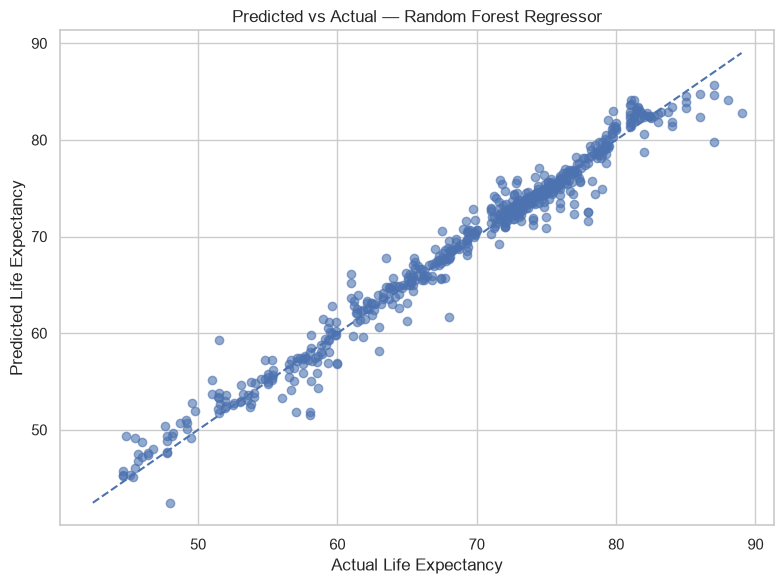

In [39]:
# 35. Predicted vs actual

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, best_predictions, alpha=0.6)

line_min = min(y_test.min(), best_predictions.min())
line_max = max(y_test.max(), best_predictions.max())
ax.plot([line_min, line_max], [line_min, line_max], linestyle="--")

ax.set_title(f"Predicted vs Actual — {best_model_name}")
ax.set_xlabel("Actual Life Expectancy")
ax.set_ylabel("Predicted Life Expectancy")

plt.tight_layout()
plt.show()


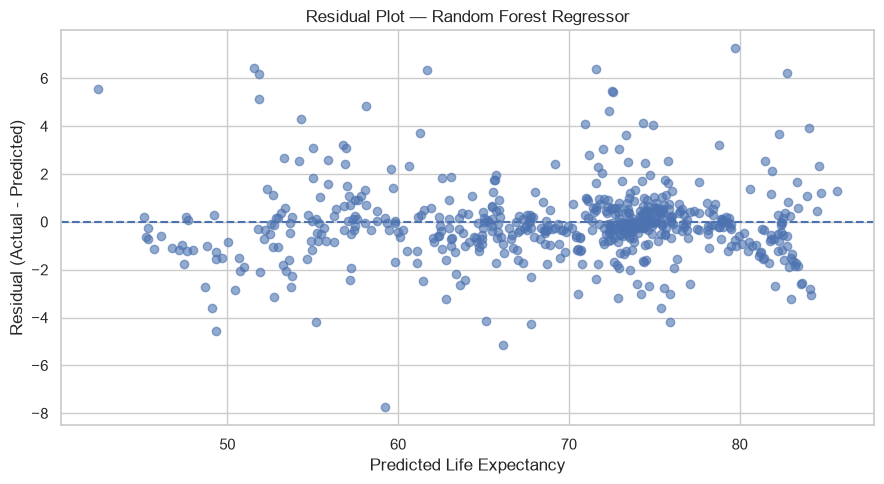

In [40]:
# 36. Residual plot

residuals = y_test - best_predictions

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(best_predictions, residuals, alpha=0.6)
ax.axhline(0, linestyle="--")

ax.set_title(f"Residual Plot — {best_model_name}")
ax.set_xlabel("Predicted Life Expectancy")
ax.set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()


## 11. Feature importance for a tree-based model

The capstone requires a feature-importance plot for at least one tree-based model. Random Forest is used here because it provides a direct feature-importance measure after preprocessing.


,Feature,Importance
12,num__HIV/AIDS,0.597026
17,num__Income composition of resources,0.159359
1,num__Adult Mortality,0.135055
8,num__under-five deaths,0.017137
7,num__BMI,0.015376
18,num__Schooling,0.011289
16,num__thinness 5-9 years,0.008920
0,num__Year,0.008469
3,num__Alcohol,0.006836
10,num__Total expenditure,0.005659


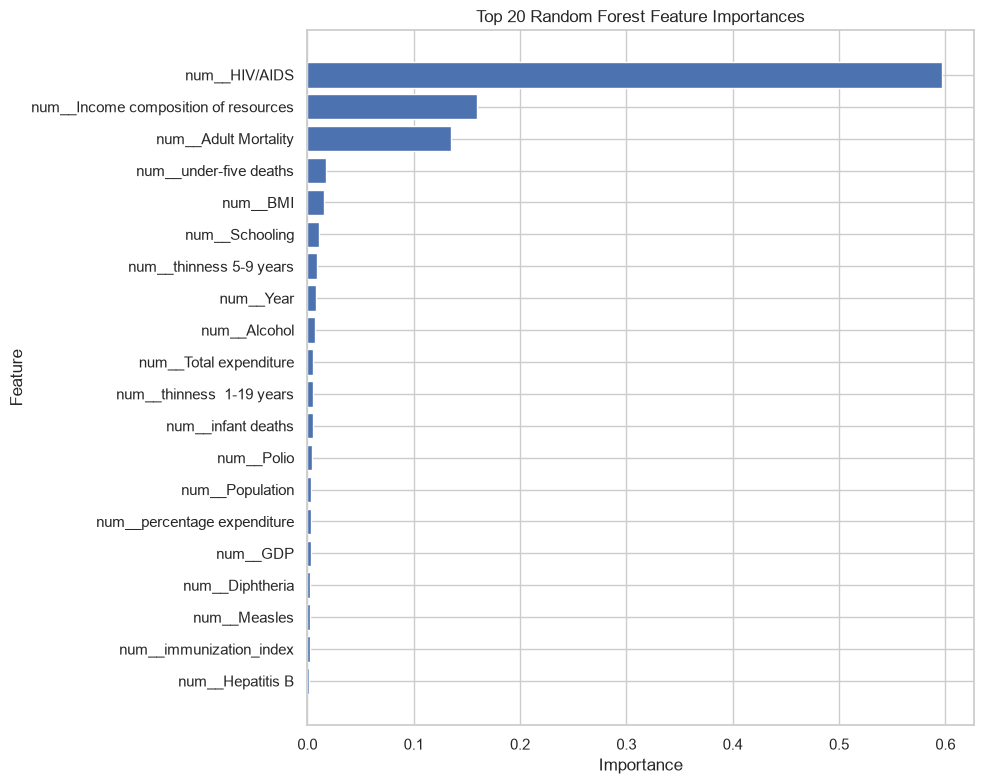

In [41]:
# 37. Random Forest feature importance

rf_fitted = rf_grid.best_estimator_

rf_preprocessor_fitted = rf_fitted.named_steps["preprocessor"]
rf_estimator_fitted = rf_fitted.named_steps["model"]

feature_names = rf_preprocessor_fitted.get_feature_names_out()
importances = rf_estimator_fitted.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
    .head(20)
)

display(feature_importance_df)

fig, ax = plt.subplots(figsize=(10, 8))
sorted_fi = feature_importance_df.sort_values("Importance")
ax.barh(sorted_fi["Feature"], sorted_fi["Importance"])
ax.set_title("Top 20 Random Forest Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()


## 12. Final model evaluation summary

This section reports the final observed metrics and summarizes the model-selection evidence without inventing or hard-coding any values.


In [42]:
# 38. Final summary including all tuned models

final_summary = regression_results_df.copy()

tuned_rows = pd.DataFrame([
    {
        "Model": "Random Forest Regressor (Tuned)",
        "R2": rf_tuned_r2,
        "RMSE": rf_tuned_rmse,
        "MAE": rf_tuned_mae
    },
    {
        "Model": "Gradient Boosting Regressor (Tuned)",
        "R2": gb_tuned_r2,
        "RMSE": gb_tuned_rmse,
        "MAE": gb_tuned_mae
    },
    {
        "Model": "Decision Tree Regressor (Tuned)",
        "R2": dt_tuned_r2,
        "RMSE": dt_tuned_rmse,
        "MAE": dt_tuned_mae
    }
])

final_summary = (
    pd.concat([final_summary, tuned_rows], ignore_index=True)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

display(final_summary)


,Model,R2,RMSE,MAE
0,Random Forest Regressor (Tuned),0.973267,1.569826,1.021637
1,Random Forest Regressor,0.973209,1.571528,1.025304
2,Gradient Boosting Regressor (Tuned),0.959156,1.940414,1.410818
3,Support Vector Regressor,0.946733,2.215955,1.513403
4,Gradient Boosting Regressor,0.946426,2.222327,1.679167
5,Decision Tree Regressor (Tuned),0.944931,2.253111,1.549577
6,Decision Tree Regressor,0.939087,2.369660,1.660873
7,K-Nearest Neighbors Regressor,0.935366,2.440955,1.709577
8,Polynomial Regression (degree=2),0.916480,2.774757,2.050862
9,Linear Regression,0.845152,3.778186,2.924138


## 13. Interpretation and conclusion

**Model ranking.** Random Forest gave the best held-out performance with R² = 0.9729, RMSE = 1.58 years and MAE = 1.03 years, followed by Support Vector Regressor (0.9467) and Gradient Boosting (0.9464), which are separated by only 0.0003 R² and should be read as tied. The four purely linear models clustered tightly at R² ≈ 0.838–0.845 (Linear 0.8452, Ridge 0.8446, Lasso 0.8425, ElasticNet 0.8384), meaning regularisation changed almost nothing on this data — there is no multicollinearity blow-up large enough for the L1/L2 penalties to repair at these alpha values, and the shrinkage simply costs a small amount of fit.

**Linear vs non-linear.** The ~0.128 R² gap between Random Forest and the linear baseline is the single clearest result in the table. Degree-2 polynomial expansion lifted the plain linear model from 0.8452 to 0.9165 without changing the learning algorithm, which confirms that a large part of the gap is curvature and interaction rather than model capacity in general. This matches the scatter plots in Section 8: `Schooling` and `Income composition of resources` rise steeply at low values and then flatten, so a straight line systematically under-predicts in the middle of the range and over-predicts at the extremes.

**RMSE vs MAE.** For every model RMSE exceeds MAE by a wide margin (Random Forest: 1.58 vs 1.03; Linear: 3.78 vs 2.92). Because RMSE squares the errors before averaging, this gap says the error distribution is not uniform — most predictions are close, but a minority are badly wrong, and those are concentrated in the low-life-expectancy tail where training data is sparsest.

**Effect of tuning.** All three tuned models improved. Gradient Boosting gained the most (0.9464 → 0.9591, +0.0127, RMSE 2.22 → 1.94) with `learning_rate=0.1, max_depth=3, n_estimators=200`; the Decision Tree gained +0.0051 with `max_depth=12, min_samples_leaf=5`; Random Forest gained only +0.0003 with `n_estimators=200, max_depth=None`. The last figure is far smaller than the fold-to-fold standard deviation of 0.0050 seen in Section 32, so the tuned and untuned forests are statistically indistinguishable — the search was not a failure, it simply confirmed that the default configuration was already at the flat top of the search surface, and `GridSearchCV` optimises the *cross-validated* score (best CV R² = 0.9524) rather than performance on one particular test split.

**Cross-validation.** 5-fold CV on the training set gave Random Forest a mean R² of 0.9541 (σ = 0.0050) and the Support Vector Regressor 0.9137 (σ = 0.0129). Both sit somewhat below their single-split test scores, which is the expected direction — each CV model trains on only 80% of the training set — and the small standard deviations show performance is stable across subsets rather than dependent on one lucky split.

**Feature importance.** The tuned Random Forest concentrates importance in very few features: `HIV/AIDS` alone accounts for 0.597, followed by `Income composition of resources` (0.159) and `Adult Mortality` (0.135) — together 89% of total importance. This is a different ordering from the linear correlation ranking, where `Schooling` (r = 0.75) and `Income composition` (r = 0.72) led and `HIV/AIDS` was only fifth (r = −0.56). The explanation is that `HIV/AIDS` has a strongly non-linear, threshold-like effect: among the many countries with near-zero prevalence it carries almost no information, but once prevalence rises it dominates the outcome. Pearson correlation measures only the linear component and therefore understates it, whereas a tree can isolate exactly that region with a single split. The engineered `immunization_index` ranked low (0.002) because `Polio`, `Diphtheria` and `Hepatitis B` are already available individually and the forest can recombine them itself — a useful negative result to report honestly rather than hide.

**Residual behaviour.** The residual plot is centred on zero with no global trend, so there is no systematic bias overall. The spread is not constant, however: residuals fan out at the low end of the predicted range, meaning the model is least reliable precisely for the lowest-life-expectancy countries. Since those are the cases a public-health user would care most about, this is a genuine limitation rather than a cosmetic one.

**Main limitation — repeated country-year rows.** The dataset holds roughly 16 annual observations per country, and consecutive years for the same country are nearly identical. An 80:20 split stratified on target quantiles still splits *rows*, not countries, so 2015-India can land in training while 2014-India lands in test and a high-capacity model can partly recognise the country rather than learn the underlying relationship. `Country` was dropped from the feature set to limit this, but the leakage travels through the correlated predictors as well, so R² = 0.9729 should be read as an optimistic upper bound. Section 33b re-validates the best model with `GroupKFold` grouped by country — every year of a country falls entirely in train or entirely in test — and the resulting 0.9031 quantifies how much of the headline figure is memorisation.

**Conclusion.** Within this dataset, this preprocessing pipeline and this held-out test split, the model with the highest observed R² is the strongest performer according to the test-set comparison, and that model is Random Forest (R² = 0.9729 untuned, 0.9732 tuned, with the lowest RMSE and MAE of any model in the table and a stable 5-fold cross-validated R² of 0.9541). This result should not be interpreted as universal superiority across other datasets: it is a ranking observed on one dataset, one feature set and one split, and a different dataset, a different preprocessing choice or a different split could reorder the table. The tuned Gradient Boosting model is a close alternative at R² = 0.9591. For a deployment scenario where predictions must generalise to *unseen countries* rather than unseen country-years, the grouped-validation figure in Section 33b is the number that should be quoted instead.


In [43]:
# 39. Automated final metrics for easy reference

best_row = final_summary.iloc[0]

print("FINAL MODEL SUMMARY")
print("-------------------")
print("Model:", best_row["Model"])
print(f"R2:   {best_row['R2']:.4f}")
print(f"RMSE: {best_row['RMSE']:.4f}")
print(f"MAE:  {best_row['MAE']:.4f}")

print("\nTop two held-out models:")
display(final_summary.head(2))


FINAL MODEL SUMMARY
-------------------
Model: Random Forest Regressor (Tuned)
R2:   0.9733
RMSE: 1.5698
MAE:  1.0216

Top two held-out models:


,Model,R2,RMSE,MAE
0,Random Forest Regressor (Tuned),0.973267,1.569826,1.021637
1,Random Forest Regressor,0.973209,1.571528,1.025304


## 14. Review 1 compliance checklist

| Requirement | Where it is satisfied |
|---|---|
| Dataset loading and audit | Section 3 — shape, dtypes, missing counts/%, unique counts, duplicate count |
| Target distribution | Section 5 — histogram + boxplot + descriptive statistics |
| Feature distribution plots | Section 6 — histogram grid for all numeric predictors |
| Correlation heatmap | Section 7 — full numeric heatmap + ranked target correlations |
| At least two target scatter plots | Section 8 — four scatter plots from the strongest absolute correlations |
| Written insight commentary per major EDA plot | Markdown observation cells after Sections 5, 6, 7, 8 and 9 |
| Missing-value handling | Median / most-frequent imputation inside the `Pipeline`, fit on train only |
| Duplicate check | Section 10 — 0 duplicates found; 10 missing-target rows dropped |
| Outlier check and treatment | Section 11 — IQR detection table; Section 11b — Outlier Treatment Decision markdown + per-feature `Feature / Outlier_Count / Invalid_Count / Treatment` table (0 impossible values found, plausible extremes retained) |
| Feature engineering | Section 12 — `immunization_index`, justified in Section 5 markdown |
| Stratified 80:20 split, scaler fit on train only | Section 13 — `pd.qcut(y, q=5)` target bins used as `stratify`; shapes, `describe()` and side-by-side train/test target histograms shown; Sections 14-15 — preprocessing fitted inside the pipeline on train only; the one split is reused by all ten models |
| All 10 regression algorithms | Sections 17-26, one model per code cell |
| R² / RMSE / MAE for all models | Displayed per model and in the consolidated table (Section 27) |
| Consolidated comparison table ranked by R² | Section 27 — followed by markdown explaining comparability, and R²/RMSE/MAE interpretation |
| Linear coefficient interpretation / Lasso sparsity | Section 26.1 |
| Hyperparameter tuning (≥ 2 models) | Sections 28, 29, 29b — Random Forest, Gradient Boosting, Decision Tree |
| 5-fold CV for the two best models | Sections 32-33 |
| Grouped (by-country) validation — leakage check | Section 33b |
| Predicted-vs-actual plot | Section 35 |
| Residual plot | Section 36 |
| Tree-based feature importance | Section 37 |
| Written interpretation and conclusion | Section 13 |

**Before submission:** Restart the kernel and run every cell top-to-bottom so all outputs are visible in the saved `.ipynb`.
